In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import re


In [3]:
import pandas as pd

files = [
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv'
]

def try_load(f):
    try:
        df = pd.read_csv(f, low_memory=False)
        print(f"\n--- {f} LOADED with comma ---")
        print("Columns:", df.columns[:10])
        return df
    except Exception:
        try:
            df = pd.read_csv(f, sep=';', low_memory=False)
            print(f"\n--- {f} LOADED with semicolon ---")
            print("Columns:", df.columns[:10])
            return df
        except:
            print(f"\n--- FAILED TO LOAD {f} ---")
            return None

dfs = []

for f in files:
    temp = try_load(f)
    if temp is None:
        continue

    # normalize column names
    temp.columns = temp.columns.str.strip().str.lower()

    if "label" not in temp.columns:
        print(f"❌ NO label column in {f}. Columns:", temp.columns[:15])
        continue

    print(f"✅ Found label in {f}")
    dfs.append(temp)

print("\nFILES THAT LOADED CORRECTLY:", len(dfs))


--- Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv LOADED with comma ---
Columns: Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std'],
      dtype='object')
✅ Found label in Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv

--- Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv LOADED with comma ---
Columns: Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std'],
      dtype='object')
✅ Found label in Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv

--- Friday-WorkingHours-Morning.pcap_ISCX.csv LOADED with com

In [4]:
# Combine all DataFrames into one
df = pd.concat(dfs, ignore_index=True)

print("Combined dataset shape:", df.shape)
print(df['label'].value_counts())

Combined dataset shape: (2209664, 79)
label
BENIGN                        1896562
PortScan                       158930
DDoS                           128027
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 2331
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Name: count, dtype: int64


In [5]:


# Fix weird symbols in labels using regex to strip non-ASCII or normalize
df['label'] = df['label'].str.encode('ascii', errors='replace').str.decode('ascii')
df['label'] = df['label'].str.replace(r'\?+', '', regex=True).str.strip()

print(df['label'].value_counts())

label
BENIGN                       1896562
PortScan                      158930
DDoS                          128027
FTP-Patator                     7938
SSH-Patator                     5897
DoS slowloris                   5796
DoS Slowhttptest                2331
Bot                             1966
Web Attack  Brute Force         1507
Web Attack  XSS                  652
Infiltration                      36
Web Attack  Sql Injection         21
Name: count, dtype: int64


In [6]:
# Separate features and target
X = df.drop(columns=['label'])
y = df['label']

# Drop non-numeric columns (IPs, timestamps, etc.) if any slipped in
X = X.select_dtypes(include=[np.number])

# Replace infinities and NaNs — XGBoost can't handle these
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)

print("Feature matrix shape:", X.shape)

Feature matrix shape: (2209664, 78)


In [7]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)
print("Encoded:", np.unique(y_encoded))

Classes: ['BENIGN' 'Bot' 'DDoS' 'DoS Slowhttptest' 'DoS slowloris' 'FTP-Patator'
 'Infiltration' 'PortScan' 'SSH-Patator' 'Web Attack  Brute Force'
 'Web Attack  Sql Injection' 'Web Attack  XSS' nan]
Encoded: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]


In [8]:
# Drop classes with fewer than 50 samples — too few to learn from reliably
min_samples = 50
counts = df['label'].value_counts()
df = df[df['label'].isin(counts[counts >= min_samples].index)].copy()

print("Remaining classes:")
print(df['label'].value_counts())
# Sql Injection (21) and Infiltration (36) will be dropped
# All others have 652+ samples — fine for training

# Re-run feature/label prep from scratch
X = df.drop(columns=['label'])
X = X.select_dtypes(include=[np.number])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)

le = LabelEncoder()
y_encoded = le.fit_transform(df['label'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("\nSplit successful!")
print("Train:", X_train.shape, "| Test:", X_test.shape)

Remaining classes:
label
BENIGN                     1896562
PortScan                    158930
DDoS                        128027
FTP-Patator                   7938
SSH-Patator                   5897
DoS slowloris                 5796
DoS Slowhttptest              2331
Bot                           1966
Web Attack  Brute Force       1507
Web Attack  XSS                652
Name: count, dtype: int64

Split successful!
Train: (1767684, 78) | Test: (441922, 78)


In [9]:
from collections import Counter

class_counts = Counter(y_train)
total = sum(class_counts.values())

# scale_pos_weight works for binary; for multiclass use sample_weight instead
sample_weights = np.array([
    total / (len(class_counts) * class_counts[label])
    for label in y_train
])

In [10]:
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',       # multiclass log loss
    objective='multi:softprob',   # multiclass classification
    num_class=len(le.classes_),
    tree_method='hist',           # fast histogram method — good for large data
    n_jobs=-1,                    # use all CPU cores
    random_state=42
)

model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    verbose=50                    # print loss every 50 rounds
)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:14:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-mlogloss:1.91803
[50]	validation_0-mlogloss:0.03206
[100]	validation_0-mlogloss:0.00956
[150]	validation_0-mlogloss:0.00724
[200]	validation_0-mlogloss:0.00668
[250]	validation_0-mlogloss:0.00646
[299]	validation_0-mlogloss:0.00631


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [11]:
y_pred = model.predict(X_test)

# Decode back to original label names
y_pred_labels = le.inverse_transform(y_pred)
y_test_labels  = le.inverse_transform(y_test)

print(classification_report(y_test_labels, y_pred_labels))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_labels, y_pred_labels))

                         precision    recall  f1-score   support

                 BENIGN       1.00      1.00      1.00    379313
                    Bot       0.66      0.99      0.80       393
                   DDoS       1.00      1.00      1.00     25606
       DoS Slowhttptest       0.99      0.99      0.99       466
          DoS slowloris       1.00      0.99      1.00      1159
            FTP-Patator       1.00      1.00      1.00      1588
               PortScan       0.99      1.00      1.00     31786
            SSH-Patator       1.00      1.00      1.00      1180
Web Attack  Brute Force       0.74      0.76      0.75       301
        Web Attack  XSS       0.40      0.41      0.40       130

               accuracy                           1.00    441922
              macro avg       0.88      0.91      0.89    441922
           weighted avg       1.00      1.00      1.00    441922


Confusion Matrix:
[[378923    199      4      6      2      0    176      0      1    

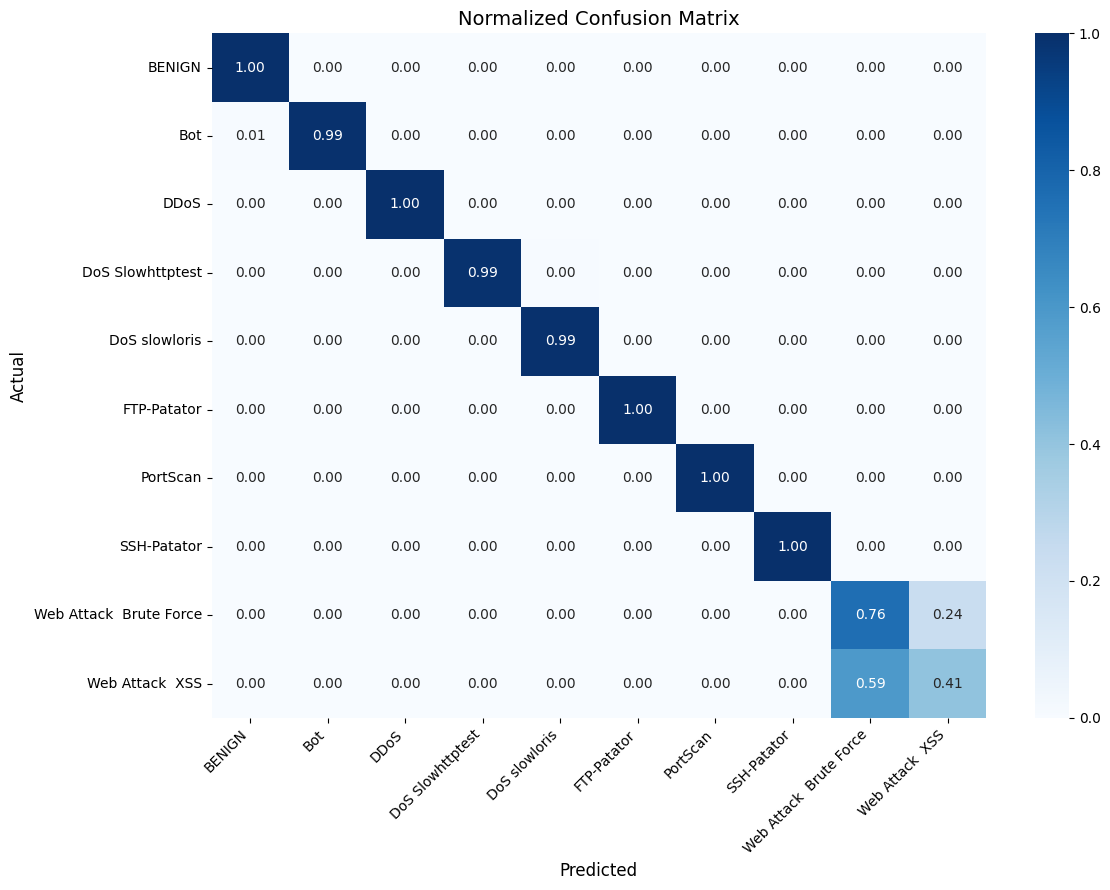

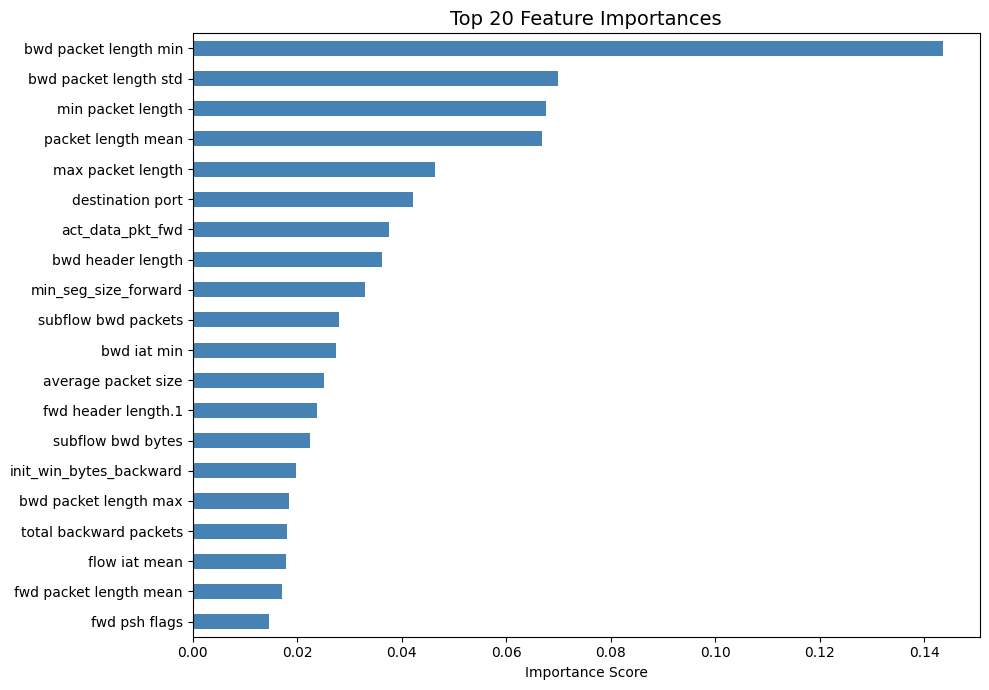

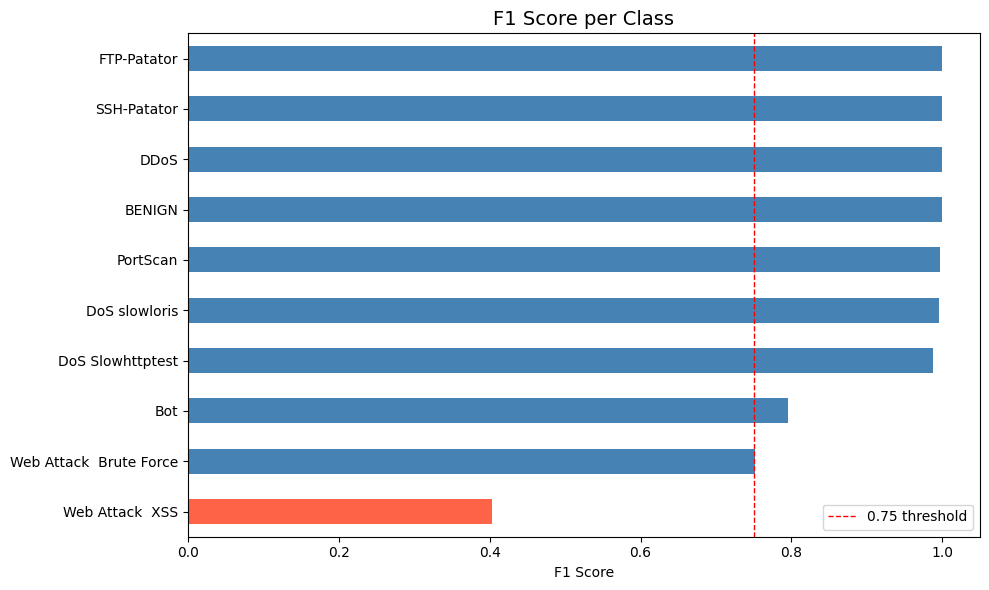

✅ Model saved to xgb_ids_model.pkl


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize
import pickle

# ── 1. Normalized Confusion Matrix ──────────────────────────────────────────
cm = confusion_matrix(y_test_labels, y_pred_labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Normalized Confusion Matrix', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ── 2. Feature Importance (top 20) ──────────────────────────────────────────
feat_imp = pd.Series(model.feature_importances_, index=X.columns)
top20 = feat_imp.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Feature Importances', fontsize=14)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

# ── 3. Class-level F1 bar chart ──────────────────────────────────────────────
from sklearn.metrics import f1_score

f1_scores = f1_score(y_test_labels, y_pred_labels, average=None, labels=le.classes_)
f1_df = pd.Series(f1_scores, index=le.classes_).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tomato' if v < 0.75 else 'steelblue' for v in f1_df.values]
f1_df.plot(kind='barh', ax=ax, color=colors)
ax.axvline(x=0.75, color='red', linestyle='--', linewidth=1, label='0.75 threshold')
ax.set_title('F1 Score per Class', fontsize=14)
ax.set_xlabel('F1 Score')
ax.set_xlim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig('f1_per_class.png', dpi=150)
plt.show()

# ── Save model ───────────────────────────────────────────────────────────────
with open('xgb_ids_model.pkl', 'wb') as f:
    pickle.dump({'model': model, 'label_encoder': le, 'feature_names': list(X.columns)}, f)

print("✅ Model saved to xgb_ids_model.pkl")

In [13]:
import pickle

with open('xgb_ids_model.pkl', 'wb') as f:
    pickle.dump({
        'model': model,
        'label_encoder': le,
        'feature_names': list(X.columns)
    }, f)

print("✅ Model re-saved with current environment versions")

✅ Model re-saved with current environment versions


In [14]:
pip install --upgrade scikit-learn

In [ ]:
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:53:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=4, ...)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    126466
           1       1.00      1.00      1.00     25606
           2       1.00      1.00      1.00     31786
           3       0.87      0.85      0.86       393

    accuracy                           1.00    184251
   macro avg       0.97      0.96      0.96    184251
weighted avg       1.00      1.00      1.00    184251

[[126413      2      3     48]
 [     4  25602      0      0]
 [     1      0  31784      1]
 [    60      0      0    333]]


Label
0    18994
1     2438
Name: count, dtype: int64


In [ ]:
Label
0    632332
2    158930
1    128027
3      1966
Name: count, dtype: int64